### Use this notebook only if recreation of dataframe is needed

In [1]:
import numpy as np
import pandas as pd
import random
from scipy.special import expit

In [ ]:
def generate_uk_home_insurance_data(n_records=1000):
    """
    Generate realistic UK home insurance data based on demographics and market research.
    Returns: List of dictionaries with insurance policy data
    """
    
    data = []
    
    # Product categories based on UK market
    products = ['Buildings', 'Contents', 'Combined', 'Landlord', 'Premium Combined', 'Standard']
    
    # Occupation distribution (UK weighted)
    occupations = {
        'retired': 0.28,
        'housewife': 0.08,
        'professional': 0.22,
        'white_collar': 0.30,
        'skilled_worker': 0.08,
        'other': 0.04
    }
    
    # Property type distribution (UK 2024)
    property_types = {
        'Terraced': 0.26,
        'Semi': 0.24,
        'Flat': 0.24,
        'Detached': 0.19,
        'Bungalow': 0.07
    }
    
    # Urban/rural split (UK ~83% urban)
    urban_rural_dist = {'urban': 0.83, 'rural': 0.17}
    
    for i in range(n_records):
        # Basic policy info
        policy_no = 100000 + i
        policy_product = random.choice(products)
        
        # Occupation
        cust_occupation = random.choices(
            list(occupations.keys()),
            weights=list(occupations.values())
        )[0]
        
        # Tier (1=basic, 2=standard, 3=premium)
        tier = random.choices([1, 2, 3], weights=[0.35, 0.50, 0.15])[0]
        
        # Tier-based premium amounts
        tier_premium_base = {1: 180, 2: 320, 3: 580}
        tier_premium_amt = tier_premium_base[tier] * random.uniform(0.85, 1.15)
        
        # Property type
        property_type = random.choices(
            list(property_types.keys()),
            weights=list(property_types.values())
        )[0]
        
        # Occupants (1-6, weighted toward 2-4)
        occupants_count = random.choices([1, 2, 3, 4, 5, 6], weights=[0.15, 0.30, 0.25, 0.20, 0.07, 0.03])[0]
        
        # Paying guests (0-2, mostly 0)
        paying_guest_no = random.choices([0, 1, 2], weights=[0.92, 0.06, 0.02])[0]
        
        # Business use (5% have it)
        business_use = 'Y' if random.random() < 0.05 else 'N'
        
        # Unoccupied days (90% have 0, rest have 30/60/90)
        unoccupied_days = random.choices([0, 30, 60, 90], weights=[0.90, 0.05, 0.03, 0.02])[0]
        unoccupied_reason = random.choice(['', 'holiday_home', 'renovation', 'relocation']) if unoccupied_days > 0 else ''
        
        # Owner details
        owner_details = random.choices(
            ['owner', 'user', 'legal_lease', 'financier'],
            weights=[0.75, 0.15, 0.08, 0.02]
        )[0]
        
        # Sum insured (rebuild cost, varies by property type)
        base_sum_insured = {
            'Flat': 200000,
            'Terraced': 300000,
            'Semi': 350000,
            'Bungalow': 320000,
            'Detached': 500000
        }
        sum_insured = int(base_sum_insured[property_type] * random.uniform(0.7, 1.8) / 50000) * 50000
        
        # Premium calculations (realistic UK ranges)
        base_premium = tier_premium_amt
        
        # Adjust for property type
        property_multipliers = {'Flat': 1.15, 'Terraced': 0.95, 'Semi': 1.0, 'Bungalow': 0.98, 'Detached': 1.25}
        base_premium *= property_multipliers[property_type]
        
        # Risk premiums
        risk_premium_with_credit_score = base_premium * random.uniform(0.92, 0.98)
        risk_premium_without_credit_score = risk_premium_with_credit_score * random.uniform(1.05, 1.15)
        
        # Premium with tax (12% insurance premium tax in UK)
        premium_with_tax = risk_premium_with_credit_score * 1.12
        
        # Coverage selected (70% yes)
        coverage_selected = 1 if random.random() < 0.70 else 0
        
        # Additional coverage amount
        additional_coverage_amount = random.choice([0, 5000, 10000, 15000, 25000]) if coverage_selected else 0
        
        # Tier limits and values
        tier_limit_value = tier * 50000
        tier_risk_premium = tier_premium_amt * 0.85
        item_limit_value = random.choice([5000, 10000, 15000, 20000])
        
        # Component premiums
        main_part_premium = base_premium * 0.65
        accidental_damage_premium = base_premium * 0.20 if random.random() < 0.60 else 0
        outbuildings_premium = base_premium * 0.10 if property_type in ['Detached', 'Semi', 'Bungalow'] and random.random() < 0.35 else 0
        
        # Auto renewal flag
        APR_FLAG = 1 if random.random() < 0.55 else 0
        
        # Previous insurance (70% had buildings, 65% had contents)
        previous_insurance_buildings = 1 if random.random() < 0.70 else 0
        previous_insurance_cne = 1 if random.random() < 0.65 else 0
        
        # Property eligibility (contents covered with house)
        property_eligibility = 1 if policy_product in ['Combined', 'Premium Combined'] else 0
        
        # Risk override tax
        risk_premium_override_tax = risk_premium_with_credit_score * 0.08 * random.uniform(0.8, 1.2)
        
        # Claims history (most have 0, few have 1-3)
        contents_claim_counts = random.choices([0, 1, 2, 3], weights=[0.82, 0.12, 0.04, 0.02])[0]
        building_claim_count = random.choices([0, 1, 2, 3], weights=[0.85, 0.10, 0.03, 0.02])[0]
        
        # Risk scores (1-5, weighted toward middle)
        flood_risk = random.choices([1, 2, 3, 4, 5], weights=[0.40, 0.30, 0.20, 0.07, 0.03])[0]
        storm_risk = random.choices([1, 2, 3, 4, 5], weights=[0.35, 0.30, 0.22, 0.10, 0.03])[0]
        other_natural_calamities_risk = random.choices([1, 2, 3, 4, 5], weights=[0.45, 0.28, 0.18, 0.07, 0.02])[0]
        
        # Property age (years) - UK has old housing stock
        property_age_bands = {
            'pre_1900': (125, 200),
            '1900_1944': (80, 124),
            '1945_1980': (44, 79),
            '1981_2000': (24, 43),
            '2001_2020': (4, 23),
            'post_2020': (0, 3)
        }
        age_band = random.choices(
            list(property_age_bands.keys()),
            weights=[0.20, 0.25, 0.28, 0.15, 0.10, 0.02]
        )[0]
        property_age = random.randint(*property_age_bands[age_band])
        
        # Construction and roof materials
        construction_material = random.choices(
            ['bricks', 'cement', 'wood', 'stone'],
            weights=[0.70, 0.20, 0.05, 0.05]
        )[0]
        roof_material = random.choices(
            ['tiles', 'slate', 'cement', 'wood'],
            weights=[0.55, 0.25, 0.15, 0.05]
        )[0]
        
        # Number of rooms (1-6+, weighted by property type)
        if property_type == 'Flat':
            no_of_rooms = random.choices([1, 2, 3, 4], weights=[0.25, 0.45, 0.25, 0.05])[0]
        elif property_type == 'Terraced':
            no_of_rooms = random.choices([2, 3, 4, 5], weights=[0.15, 0.55, 0.25, 0.05])[0]
        elif property_type == 'Semi':
            no_of_rooms = random.choices([2, 3, 4, 5], weights=[0.10, 0.45, 0.35, 0.10])[0]
        elif property_type == 'Bungalow':
            no_of_rooms = random.choices([2, 3, 4], weights=[0.35, 0.50, 0.15])[0]
        else:  # Detached
            no_of_rooms = random.choices([3, 4, 5, 6], weights=[0.20, 0.40, 0.30, 0.10])[0]
        
        # Plumbing/electrical age (0-50 years)
        plumbing_elec_age = min(property_age, random.randint(5, 40))
        
        # Smart home, fire safety, security (increasing adoption)
        smart_home = 1 if random.random() < 0.28 else 0
        fire_safety_systems = 1 if random.random() < 0.45 else 0
        security_systems = 1 if random.random() < 0.52 else 0
        
        # Crime rate (1-5, area dependent)
        urban_rural = random.choices(
            list(urban_rural_dist.keys()),
            weights=list(urban_rural_dist.values())
        )[0]
        if urban_rural == 'urban':
            crime_rate = random.choices([1, 2, 3, 4, 5], weights=[0.15, 0.30, 0.35, 0.15, 0.05])[0]
        else:
            crime_rate = random.choices([1, 2, 3, 4, 5], weights=[0.40, 0.35, 0.18, 0.05, 0.02])[0]
        
        # Total claims in last 5 years
        no_of_claims_5yr = contents_claim_counts + building_claim_count
        
        # Premium payment behaviour (score 0-100, higher is better)
        premium_payment_behaviour = int(random.triangular(60, 100, 85))
        
        # Property market value (higher than sum insured typically)
        property_market_value = int(sum_insured * random.uniform(1.1, 1.8) / 10000) * 10000
        
        # Short term letting (Airbnb) - about 2% of properties
        short_term_letting = 1 if random.random() < 0.02 else 0
        
        # Create record
        record = {
            'policy_no': policy_no,
            'policy_product': policy_product,
            'cust_occupation': cust_occupation,
            'tier': tier,
            'tier_premium_amt': round(tier_premium_amt, 2),
            'occupants_count': occupants_count,
            'paying_guest_no': paying_guest_no,
            'business_use': business_use,
            'unoccupied_days': unoccupied_days,
            'unoccupied_reason': unoccupied_reason,
            'owner_details': owner_details,
            'sum_insured': sum_insured,
            'premium_with_tax': round(premium_with_tax, 2),
            'risk_premium_with_credit_score': round(risk_premium_with_credit_score, 2),
            'risk_premium_without_credit_score': round(risk_premium_without_credit_score, 2),
            'coverage_selected': coverage_selected,
            'additional_coverage_amount': additional_coverage_amount,
            'tier_limit_value': tier_limit_value,
            'tier_risk_premium': round(tier_risk_premium, 2),
            'item_limit_value': item_limit_value,
            'main_part_premium': round(main_part_premium, 2),
            'accidental_damage_premium': round(accidental_damage_premium, 2),
            'outbuildings_premium': round(outbuildings_premium, 2),
            'APR_FLAG': APR_FLAG,
            'previous_insurance_buildings': previous_insurance_buildings,
            'previous_insurance_cne': previous_insurance_cne,
            'property_eligibility': property_eligibility,
            'risk_premium_override_tax': round(risk_premium_override_tax, 2),
            'contents_claim_counts': contents_claim_counts,
            'building_claim_count': building_claim_count,
            'flood_risk': flood_risk,
            'storm_risk': storm_risk,
            'other_natural_calamities_risk': other_natural_calamities_risk,
            'property_age': property_age,
            'property_type': property_type,
            'construction_material': construction_material,
            'roof_material': roof_material,
            'no_of_rooms': no_of_rooms,
            'plumbing_elec_age': plumbing_elec_age,
            'smart_home': smart_home,
            'fire_safety_systems': fire_safety_systems,
            'security_systems': security_systems,
            'crime_rate': crime_rate,
            'urban_rural': urban_rural,
            'no_of_claims_5yr': no_of_claims_5yr,
            'premium_payment_behaviour': premium_payment_behaviour,
            'property_market_value': property_market_value,
            'short_term_letting': short_term_letting
        }
        
        data.append(record)
    return data

In [ ]:
data = generate_uk_home_insurance_data(500000)
df = pd.DataFrame(data)
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,plumbing_elec_age,smart_home,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting
0,100000,Combined,skilled_worker,1,166.58,4,0,N,0,,...,18,0,0,0,3,urban,0,74,880000,0
1,100001,Combined,skilled_worker,2,342.37,2,0,N,0,,...,25,0,1,1,1,rural,0,82,890000,0
2,100002,Buildings,skilled_worker,2,325.97,1,0,N,30,,...,36,0,0,0,3,urban,0,83,320000,0
3,100003,Landlord,retired,1,160.16,6,0,N,0,,...,21,0,0,1,5,urban,0,86,390000,0
4,100004,Combined,professional,1,206.89,2,0,N,0,,...,36,0,1,1,2,rural,0,71,590000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Standard,white_collar,2,310.44,4,0,N,0,,...,32,0,1,1,5,urban,0,84,610000,0
499996,599996,Combined,retired,2,279.42,4,0,N,30,relocation,...,25,0,1,0,3,urban,2,92,300000,0
499997,599997,Landlord,professional,2,336.84,4,0,N,0,,...,16,0,0,1,1,urban,0,87,1060000,0
499998,599998,Standard,white_collar,1,163.38,3,0,N,0,,...,23,0,1,1,2,urban,1,76,390000,0


In [ ]:
def generate_fraud_labels(df):
    # Create a copy to avoid modifying original
    data = df.copy()
    
    # ==================== ONE-HOT ENCODING ====================
    # Encode categorical variables
    occupation_dummies = pd.get_dummies(data['cust_occupation'], prefix='occ')
    property_type_dummies = pd.get_dummies(data['property_type'], prefix='prop')
    owner_dummies = pd.get_dummies(data['owner_details'], prefix='owner')
    urban_rural_dummies = pd.get_dummies(data['urban_rural'], prefix='location')
    product_dummies = pd.get_dummies(data['policy_product'], prefix='product')
    
    # Combine with original data
    data = pd.concat([data, occupation_dummies, property_type_dummies, 
                      owner_dummies, urban_rural_dummies, product_dummies], axis=1)
    
    # ==================== NORMALIZE KEY FEATURES ====================
    # Normalize continuous variables to [0, 1] range for consistent scaling
    data['norm_claims'] = data['no_of_claims_5yr'] / 6  # max expected is 6
    data['norm_payment'] = (100 - data['premium_payment_behaviour']) / 100  # inverse, higher is worse
    data['norm_unoccupied'] = data['unoccupied_days'] / 90
    data['norm_property_age'] = np.clip(data['property_age'] / 200, 0, 1)
    data['norm_plumbing_age'] = np.clip(data['plumbing_elec_age'] / 50, 0, 1)
    data['norm_crime'] = (data['crime_rate'] - 1) / 4  # scale 1-5 to 0-1
    data['norm_flood'] = (data['flood_risk'] - 1) / 4
    data['norm_storm'] = (data['storm_risk'] - 1) / 4
    data['norm_natural_risk'] = (data['other_natural_calamities_risk'] - 1) / 4
    
    # ==================== FRAUD RISK COMPONENTS ====================
    
    # 1. CLAIMS HISTORY COMPONENT (Weight: 30%)
    # Multiple claims are strongest fraud indicator - exponential penalty
    claims_risk = np.exp(2.5 * data['norm_claims']) - 1  # exponential growth
    # Add non-linearity for building vs contents claims mismatch
    claims_imbalance = np.abs(data['contents_claim_counts'] - data['building_claim_count'])
    claims_risk += np.sin(np.pi * claims_imbalance / 3) * 0.3
    
    # 2. PAYMENT BEHAVIOR COMPONENT (Weight: 25%)
    # Poor payment history combined with high claims is suspicious
    payment_risk = np.exp(2.0 * data['norm_payment']) - 1
    # Interaction term: bad payment + high claims = very suspicious
    payment_claims_interaction = data['norm_payment'] * data['norm_claims'] * 2.5
    payment_risk += np.tanh(payment_claims_interaction)  # bounded non-linearity
    
    # 3. PROPERTY RISK COMPONENT (Weight: 20%)
    # High natural disaster risk + unoccupied = fraud opportunity
    natural_risk_combined = (data['norm_flood'] + data['norm_storm'] + data['norm_natural_risk']) / 3
    property_risk = np.sin(np.pi * natural_risk_combined / 2) * 1.5  # sine wave peaks at high risk
    
    # Unoccupied properties are fraud risk - especially with business use
    unoccupied_factor = np.exp(1.8 * data['norm_unoccupied']) - 1
    business_multiplier = np.where(data['business_use'] == 'Y', 1.4, 1.0)
    property_risk += unoccupied_factor * business_multiplier
    
    # Old property + old plumbing = higher fraud likelihood (exaggerated damage)
    age_risk = np.sqrt(data['norm_property_age'] * data['norm_plumbing_age']) * 0.8
    property_risk += np.tanh(age_risk * 2)
    
    # 4. COVERAGE ANOMALY COMPONENT (Weight: 15%)
    # Ratio analysis: high sum insured relative to market value is suspicious
    coverage_ratio = data['sum_insured'] / (data['property_market_value'] + 1)  # avoid division by zero
    coverage_risk = np.where(coverage_ratio > 0.8, 
                            np.exp(2 * (coverage_ratio - 0.8)) - 1,
                            0)
    
    # High additional coverage with low tier is suspicious
    tier_coverage_mismatch = (data['additional_coverage_amount'] / 25000) / (data['tier'] + 1)
    coverage_risk += np.sin(np.pi * tier_coverage_mismatch) * 0.5
    
    # Premium ratio anomaly: very low risk premium vs actual premium
    premium_ratio = data['risk_premium_with_credit_score'] / (data['premium_with_tax'] + 1)
    coverage_risk += np.where(premium_ratio < 0.7, 
                             np.exp(2 * (0.7 - premium_ratio)) - 1,
                             0)
    
    # 5. DEMOGRAPHIC ANOMALY COMPONENT (Weight: 10%)
    # Certain occupation patterns combined with high claims
    demographic_risk = 0
    if 'occ_other' in data.columns:
        demographic_risk += data['occ_other'] * data['norm_claims'] * 1.5
    
    # User/legal lease (not owner) + high claims + poor payment
    if 'owner_user' in data.columns:
        demographic_risk += data['owner_user'] * data['norm_claims'] * data['norm_payment'] * 1.2
    if 'owner_legal_lease' in data.columns:
        demographic_risk += data['owner_legal_lease'] * data['norm_claims'] * data['norm_payment'] * 1.3
    
    # High crime area + no security systems
    security_deficit = (1 - data['security_systems']) * (1 - data['fire_safety_systems']) / 2
    demographic_risk += data['norm_crime'] * security_deficit * np.exp(data['norm_claims'])
    
    # Paying guests with business use
    pg_business_risk = (data['paying_guest_no'] / 2) * np.where(data['business_use'] == 'Y', 2.0, 0.5)
    demographic_risk += np.tanh(pg_business_risk)
    
    # Short-term letting (Airbnb) with high claims is very suspicious
    if 'short_term_letting' in data.columns:
        demographic_risk += data['short_term_letting'] * data['norm_claims'] * 2.5
    
    # 6. PREVIOUS INSURANCE ANOMALY (Weight: 5%)
    # No previous insurance but high claims immediately is suspicious
    insurance_history_risk = 0
    no_previous = (1 - data['previous_insurance_buildings']) * (1 - data['previous_insurance_cne'])
    insurance_history_risk = no_previous * data['norm_claims'] * 1.8
    
    # Had previous insurance but switched with high claims (possible fraud hopping)
    switched_with_claims = (data['previous_insurance_buildings'] + data['previous_insurance_cne']) / 2
    insurance_history_risk += switched_with_claims * np.exp(data['norm_claims']) * 0.3
    
    # No auto-renewal with high claims (trying to avoid scrutiny)
    insurance_history_risk += (1 - data['APR_FLAG']) * data['norm_claims'] * 0.8
    
    # ==================== WEIGHTED COMBINATION ====================
    # Combine all components with weights
    fraud_score = (
        0.30 * claims_risk +
        0.25 * payment_risk +
        0.20 * property_risk +
        0.15 * coverage_risk +
        0.05 * demographic_risk +
        0.05 * insurance_history_risk
    )
    
    # ==================== NON-LINEAR INTERACTION TERMS ====================
    # Complex fraud patterns emerge from interactions
    
    # High-value fraud: high sum insured + poor payment + high claims
    high_value_fraud = (data['sum_insured'] / 500000) * data['norm_payment'] * data['norm_claims']
    fraud_score += np.exp(high_value_fraud) * 0.1 - 0.1
    
    # Disaster opportunism: high natural risks + unoccupied + recent claims
    disaster_fraud = natural_risk_combined * data['norm_unoccupied'] * data['norm_claims']
    fraud_score += np.sin(np.pi * disaster_fraud) * 0.15
    
    # Organized fraud pattern: multiple paying guests + business + high claims
    organized_pattern = (data['paying_guest_no'] / 2) * np.where(data['business_use'] == 'Y', 1, 0) * data['norm_claims']
    fraud_score += np.tanh(organized_pattern * 2) * 0.12
    
    # ==================== CONVERT TO PROBABILITY ====================
    # Apply sigmoid to convert to probability [0, 1]
    # Adjust sigmoid steepness and center to achieve ~12-15% fraud rate (realistic for UK)
    fraud_probability = expit((fraud_score - 2.5) * 1.2)  # center at 2.5, steepness 1.2
    
    # ==================== GENERATE BINARY LABELS ====================
    # Use adaptive threshold: higher threshold for low-risk profiles
    base_threshold = 0.5
    
    # Adjust threshold based on risk factors
    adaptive_threshold = base_threshold - (
        0.15 * data['norm_claims'] +  # multiple claims lower threshold
        0.10 * data['norm_payment'] +  # poor payment lower threshold
        0.08 * data['norm_unoccupied']  # unoccupied lower threshold
    )
    adaptive_threshold = np.clip(adaptive_threshold, 0.20, 0.75)
    
    # Generate binary labels
    fraud_label = (fraud_probability > adaptive_threshold).astype(int)
    
    noise_mask = np.random.random(len(fraud_label)) < 0.02  # 2% noise
    fraud_label = np.where(noise_mask, 1 - fraud_label, fraud_label)
    
    # ==================== RETURN RESULTS ====================
    data['fraud_probability'] = fraud_probability
    # data['fraud_label'] = fraud_label
    
    return data['fraud_probability']

In [29]:
fraud_results = generate_fraud_labels(df)
df = pd.concat([df, fraud_results], axis=1)
df

,policy_no,policy_product,cust_occupation,tier,tier_premium_amt,occupants_count,paying_guest_no,business_use,unoccupied_days,unoccupied_reason,...,smart_home,fire_safety_systems,security_systems,crime_rate,urban_rural,no_of_claims_5yr,premium_payment_behaviour,property_market_value,short_term_letting,fraud_probability
0,100000,Combined,skilled_worker,1,166.58,4,0,N,0,NaN,...,0,0,0,3,urban,0,74,880000,0,0.073655
1,100001,Combined,skilled_worker,2,342.37,2,0,N,0,NaN,...,0,1,1,1,rural,0,82,890000,0,0.066178
2,100002,Buildings,skilled_worker,2,325.97,1,0,N,30,NaN,...,0,0,0,3,urban,0,83,320000,0,0.087979
3,100003,Landlord,retired,1,160.16,6,0,N,0,NaN,...,0,0,1,5,urban,0,86,390000,0,0.062205
4,100004,Combined,professional,1,206.89,2,0,N,0,NaN,...,0,1,1,2,rural,0,71,590000,1,0.089477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,599995,Standard,white_collar,2,310.44,4,0,N,0,NaN,...,0,1,1,5,urban,0,84,610000,0,0.079920
499996,599996,Combined,retired,2,279.42,4,0,N,30,relocation,...,0,1,0,3,urban,2,92,300000,0,0.128952
499997,599997,Landlord,professional,2,336.84,4,0,N,0,NaN,...,0,0,1,1,urban,0,87,1060000,0,0.063849
499998,599998,Standard,white_collar,1,163.38,3,0,N,0,NaN,...,0,1,1,2,urban,1,76,390000,0,0.111040


In [30]:
df.columns

Index(['policy_no', 'policy_product', 'cust_occupation', 'tier',
       'tier_premium_amt', 'occupants_count', 'paying_guest_no',
       'business_use', 'unoccupied_days', 'unoccupied_reason', 'owner_details',
       'sum_insured', 'premium_with_tax', 'risk_premium_with_credit_score',
       'risk_premium_without_credit_score', 'coverage_selected',
       'additional_coverage_amount', 'tier_limit_value', 'tier_risk_premium',
       'item_limit_value', 'main_part_premium', 'accidental_damage_premium',
       'outbuildings_premium', 'APR_FLAG', 'previous_insurance_buildings',
       'previous_insurance_cne', 'property_eligibility',
       'risk_premium_override_tax', 'contents_claim_counts',
       'building_claim_count', 'flood_risk', 'storm_risk',
       'other_natural_calamities_risk', 'property_age', 'property_type',
       'construction_material', 'roof_material', 'no_of_rooms',
       'plumbing_elec_age', 'smart_home', 'fire_safety_systems',
       'security_systems', 'crime_rate',

In [ ]:
def compute_correlations(df, target="fraud_probability"):
    df_corr = pd.DataFrame(columns=["feature", "correlation"])
    
    for col in df.columns:
        if col == target:
            continue
        
        # If numeric → direct Pearson
        if np.issubdtype(df[col].dtype, np.number):
            corr = df[col].corr(df[target])
        
        else:
            # Encode categorical temporarily
            corr = df[col].astype("category").cat.codes.corr(df[target])
        
        df_corr.loc[len(df_corr)] = [col, corr]
    
    return df_corr.sort_values("correlation", key=lambda x: abs(x), ascending=False)

correlations = compute_correlations(df)
print(correlations)

                              feature  correlation
48                        fraud_label     0.749287
44                   no_of_claims_5yr     0.723942
28              contents_claim_counts     0.515079
29               building_claim_count     0.508233
8                     unoccupied_days     0.471946
9                   unoccupied_reason     0.282516
45          premium_payment_behaviour    -0.144329
31                         storm_risk     0.079034
30                         flood_risk     0.078285
32      other_natural_calamities_risk     0.075570
38                  plumbing_elec_age     0.062440
33                       property_age     0.062381
16         additional_coverage_amount     0.051053
15                  coverage_selected     0.030404
7                        business_use     0.015123
6                     paying_guest_no     0.009249
3                                tier    -0.008579
17                   tier_limit_value    -0.008579
4                    tier_premi


=== Correlation with fraud_probability ===
fraud_probability                1.000000
no_of_claims_5yr                 0.723942
contents_claim_counts            0.515079
building_claim_count             0.508233
unoccupied_days                  0.471946
unoccupied_reason                0.138561
storm_risk                       0.079034
flood_risk                       0.078285
other_natural_calamities_risk    0.075570
plumbing_elec_age                0.062440
property_age                     0.062381
additional_coverage_amount       0.051053
coverage_selected                0.030404
business_use                     0.015123
paying_guest_no                  0.009249
previous_insurance_cne           0.006568
short_term_letting               0.005495
previous_insurance_buildings     0.004339
sum_insured                      0.003661
crime_rate                       0.003403
Name: fraud_probability, dtype: float64


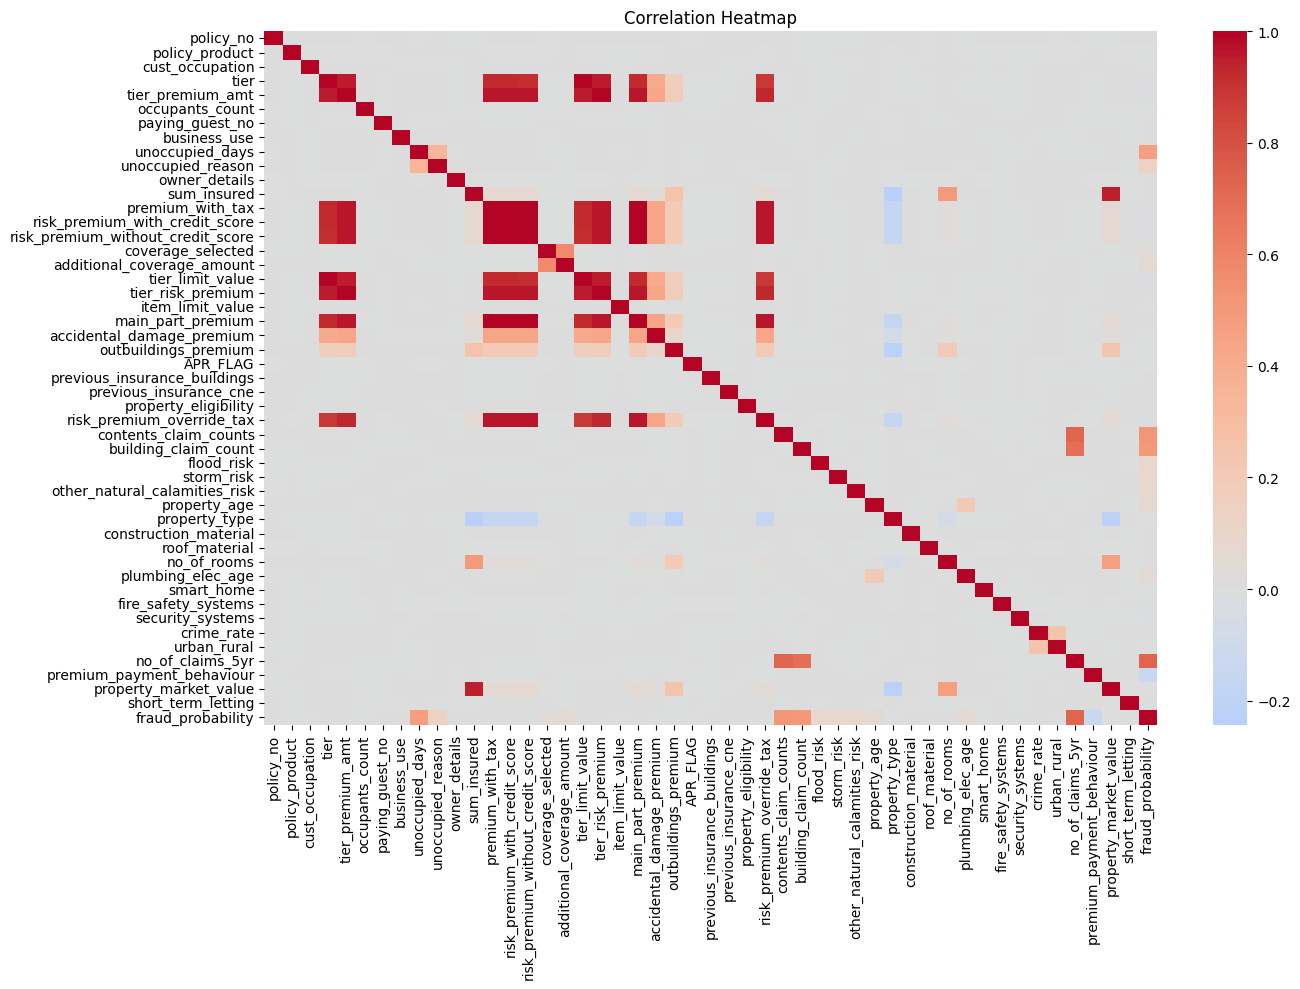


=== Missing Value % by Column ===
policy_no                            0.0
policy_product                       0.0
cust_occupation                      0.0
tier                                 0.0
tier_premium_amt                     0.0
occupants_count                      0.0
paying_guest_no                      0.0
business_use                         0.0
unoccupied_days                      0.0
unoccupied_reason                    0.0
owner_details                        0.0
sum_insured                          0.0
premium_with_tax                     0.0
risk_premium_with_credit_score       0.0
risk_premium_without_credit_score    0.0
coverage_selected                    0.0
additional_coverage_amount           0.0
tier_limit_value                     0.0
tier_risk_premium                    0.0
item_limit_value                     0.0
main_part_premium                    0.0
accidental_damage_premium            0.0
outbuildings_premium                 0.0
APR_FLAG              

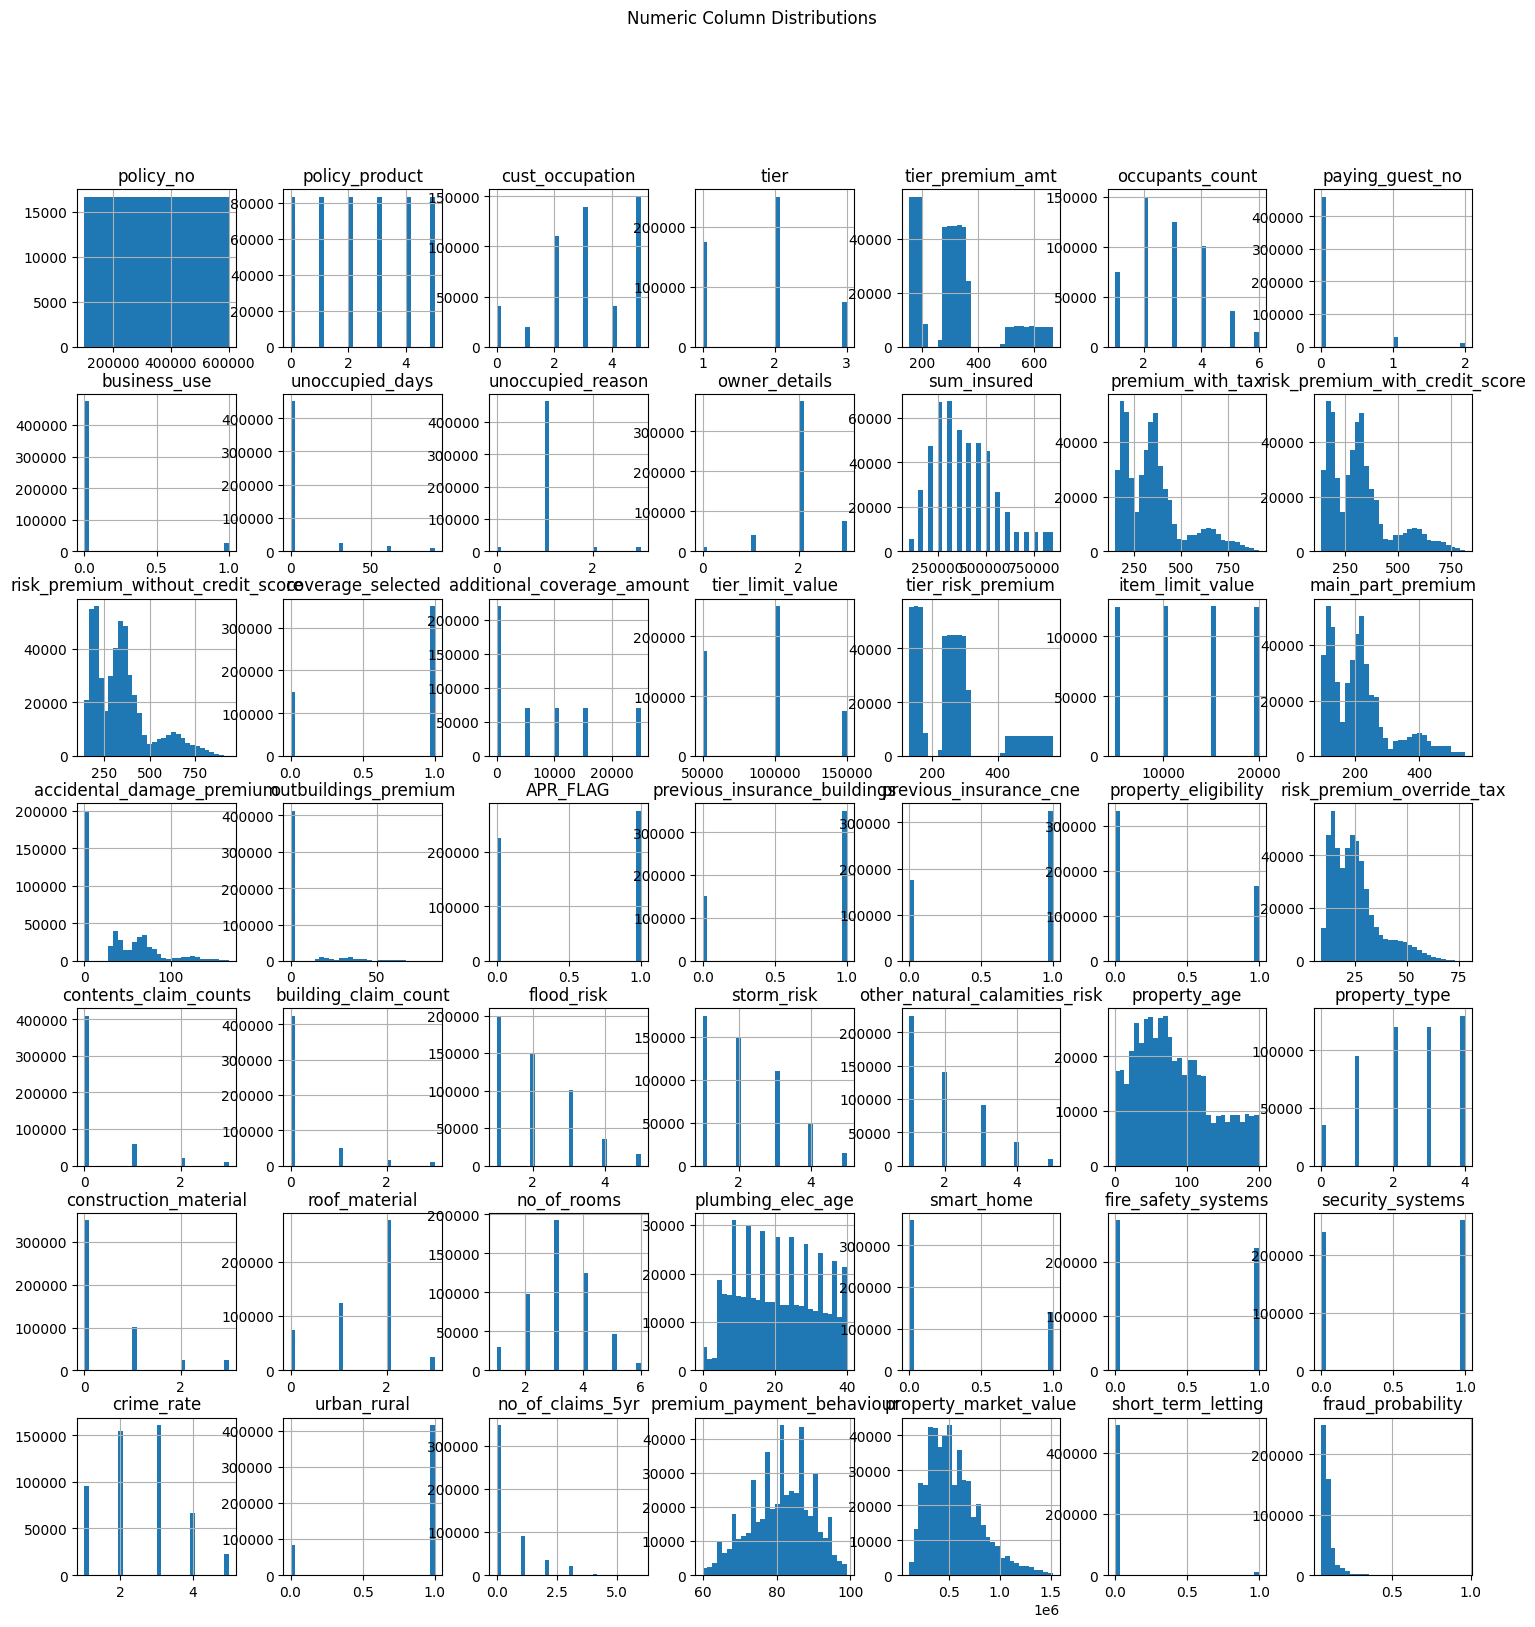


=== Category Counts (Top 20 Each) ===

--- policy_product ---
policy_product
Premium Combined    83602
Buildings           83323
Combined            83298
Standard            83280
Contents            83257
Landlord            83240
Name: count, dtype: int64

--- cust_occupation ---
cust_occupation
white_collar      149787
retired           139603
professional      110083
housewife          40383
skilled_worker     40117
other              20027
Name: count, dtype: int64

--- business_use ---
business_use
N    475061
Y     24939
Name: count, dtype: int64

--- unoccupied_reason ---
unoccupied_reason
relocation      12485
holiday_home    12444
renovation      12248
Name: count, dtype: int64

--- owner_details ---
owner_details
owner          374592
user            74914
legal_lease     40361
financier       10133
Name: count, dtype: int64

--- property_type ---
property_type
Terraced    129922
Semi        120065
Flat        119945
Detached     94851
Bungalow     35217
Name: count, dtype

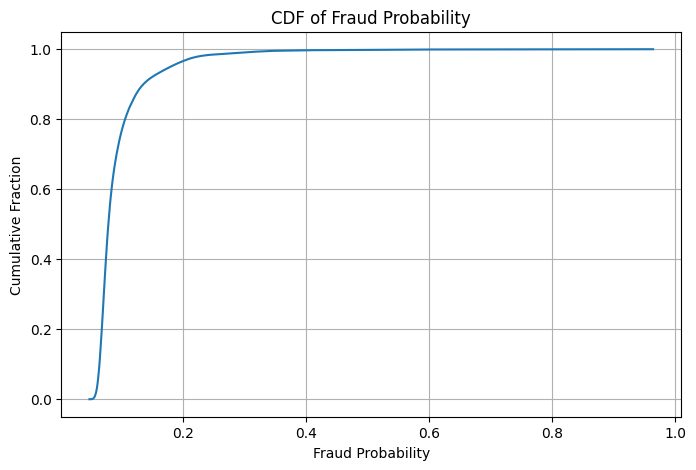


=== Recommended Thresholds ===
19% highest-risk threshold: 0.1066
9% highest-risk threshold: 0.1363
5% highest-risk threshold: 0.1803
2% highest-risk threshold: 0.2274


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. BASIC CLEANING
# ============================================
df_clean = df.copy()

# Convert categorical columns to numeric (label encoding)
from sklearn.preprocessing import LabelEncoder
cat_cols = df_clean.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))

# ============================================
# 2. CORRELATION MATRIX (label + probability)
# ============================================
corr = df_clean.corr()

corr_with_prob = corr["fraud_probability"].sort_values(ascending=False)

print("\n=== Correlation with fraud_probability ===")
print(corr_with_prob.head(20))

# ===== Heatmap =====
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ============================================
# 3. INDUSTRY-STYLE EDA TOOLS
# ============================================

# Missing values
print("\n=== Missing Value % by Column ===")
print(df_clean.isnull().mean().sort_values(ascending=False) * 100)

# Distribution of key numeric fields
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

df_clean[numeric_cols].hist(figsize=(18, 18), bins=30)
plt.suptitle("Numeric Column Distributions")
plt.show()

# High-cardinality categorical levels
print("\n=== Category Counts (Top 20 Each) ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(20))

# ============================================
# 4. FRAUD PROBABILITY CDF (CUMULATIVE CURVE)
# ============================================

fraud_probs = df["fraud_probability"].sort_values().values
cdf = np.arange(1, len(fraud_probs)+1) / len(fraud_probs)

plt.figure(figsize=(8,5))
plt.plot(fraud_probs, cdf)
plt.xlabel("Fraud Probability")
plt.ylabel("Cumulative Fraction")
plt.title("CDF of Fraud Probability")
plt.grid(True)
plt.show()

# ============================================
# 5. NUMERIC THRESHOLD FINDER
# ============================================

# Example: flag top 2%, 5%, 10%, 20% highest risk cases
percentiles = [0.80, 0.90, 0.95, 0.98]

print("\n=== Recommended Thresholds ===")
for p in percentiles:
    threshold = np.quantile(fraud_probs, p)
    print(f"{int((1-p)*100)}% highest-risk threshold: {threshold:.4f}")


In [36]:
# Set UK-standard realistic fraud threshold
uk_threshold = 0.18

df["fraud_label"] = (df["fraud_probability"] >= uk_threshold).astype(int)

print("UK-standard fraud threshold set at:", uk_threshold)
print("Fraud rate in dataset:", df["fraud_label"].mean())

UK-standard fraud threshold set at: 0.18
Fraud rate in dataset: 0.050282


In [ ]:
df.to_csv("data_5L_new.csv", index=False)